# Building my first chess engine using Python's chess package

In [3]:
import chess
import chess.svg

print(chess.__version__)

board = chess.Board
print(board)

1.11.2
<class 'chess.Board'>


## Create an image

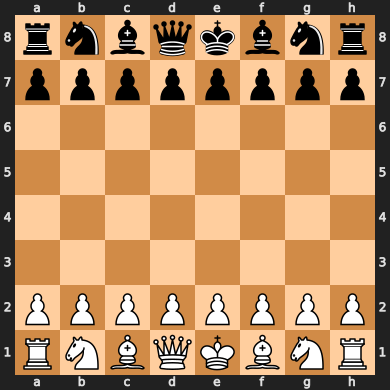

In [4]:
import io

import cairosvg
import chess
import chess.svg
from PIL import Image

starting_board = chess.Board(chess.Board.starting_fen)
image = chess.svg.board(starting_board)

png_bytes = cairosvg.svg2png(bytestring=image)  # type: ignore
Image.open(io.BytesIO(png_bytes))  # type:ignore

## Print the moves

In [ ]:
import chess
import chess.pgn

game = "chess-games/Abdusattorov.pgn"
with open(game) as f:
    first_game = chess.pgn.read_game(f)

for move in first_game.mainline_moves():
    print(move)
    print("--")

e2e4
--
c7c5
--
g1f3
--
a7a6
--
d2d3
--
g7g6
--
g2g3
--
f8g7
--
f1g2
--
b7b5
--
e1g1
--
c8b7
--
c2c3
--
e7e5
--
a2a3
--
g8e7
--
b2b4
--
d7d6
--
b1d2
--
e8g8
--
d2b3
--
b8d7
--
c1e3
--
a8c8
--
a1c1
--
h7h6
--
f3d2
--
f7f5
--
f2f4
--
g8h7
--
d1e2
--
c5b4
--
a3b4
--
e5f4
--
e3f4
--
c8c3
--
c1c3
--
g7c3
--
f4d6
--
d8b6
--
d6c5
--
d7c5
--
b4c5
--
b6e6
--
d3d4
--
f8d8
--
e2d3
--
c3d2
--
b3d2
--
f5e4
--
d2e4
--
e7f5
--
d4d5
--
e6e5
--
g3g4
--
f5e7
--
f1f7
--
h7g8
--
d3f1
--
e7d5
--
f7b7
--
e5d4
--
g1h1
--
d8f8
--
f1g1
--
d5e3
--
b7e7
--
a6a5
--
c5c6
--
a5a4
--
g1e3
--
d4e3
--
e4f6
--
f8f6
--
e7e3
--
f6d6
--
h2h4
--
d6d1
--
h1h2
--
b5b4
--
c6c7
--


## Create a gif of each move

In [ ]:
import io
import os

import cairosvg
import chess
import chess.pgn
import chess.svg
from PIL import Image


def read_game_from_pgn(filename: str) -> chess.pgn.Game:
    """"""
    directory = os.path.join(os.getcwd(), "chess-games")
    game_location = os.path.join(directory, filename)
    with open(game_location) as pgn:
        game = chess.pgn.read_game(pgn)

    if game is None:
        raise ValueError("No game found!")

    return game


def chess_movie(
    game: chess.pgn.Game,
    framerate: int = 2,
) -> bytes:
    """Take file of chess notation and produce gif showing game."""
    board = chess.Board(chess.Board.starting_fen)  # define the board

    png_bytes = cairosvg.svg2png(bytestring=chess.svg.board(board))
    if png_bytes is None:
        raise ValueError("Unable to render starting chess board")

    # create a list of frames for the gif
    starting_position_frame = Image.open(io.BytesIO(png_bytes))
    frames = []
    frames.append(starting_position_frame)

    for move in game.mainline_moves():
        # push the board for each move
        board.push(move)

        png_bytes = cairosvg.svg2png(bytestring=chess.svg.board(board))
        if png_bytes is None:
            raise ValueError("Unable to render starting chess board")
        current_position_frame = Image.open(io.BytesIO(png_bytes))
        frames.append(current_position_frame)

    # create a gif
    buffer = io.BytesIO()
    frames[0].save(
        buffer,
        format="GIF",
        save_all=True,
        append_images=frames[1:],
        duration=1000 / framerate,
        loop=0,
    )
    buffer.seek(0)
    return buffer.getvalue()

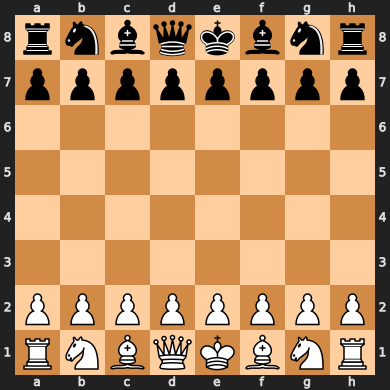

In [21]:
from IPython.display import Image as IPImage
from IPython.display import display

gif = chess_movie(read_game_from_pgn("Abdusattorov.pgn"), framerate=2)
display(IPImage(data=gif, format="png"))

# Now that we can create gif's as we please, we can now create the engine using the typical methods

The guiding principle of chess engines is to use the most efficient search algorithms possible.

We start by considering

In [1]:
import chess

## First method for chess engines

The main idea I want to implement first is just to create an engine that can take all possible moves, and then play the next one. From here, it should be relatively trivial to create a cli that can create a chess board, then export it to a gif for me to watch :D

In [ ]:
import random


def choose_move(position: chess.Board, method: str = "random") -> chess.Move:
    """Choose a move from a game, given a chess.Board object."""

    # get the board from the game
    all_moves = list(position.legal_moves)
    if len(all_moves) == 0:
        raise ValueError("Stalemate! No legal moves available.")

    if method == "random":  # return a random move from the list of legal moves
        return random.choice(all_moves)

    else:
        return random.choice(all_moves)


def play_move(position: chess.Board, method: str = "random") -> chess.Board:
    """Play a move from the chess board and return the new position"""

    move = choose_move(position, method=method)
    position.push(move)
    return position

To choose which move to use, I will consider the following setup:

1. Take the board state
2. Generate a chess.Game object using that board as the root
3. Use whichever search algorithm to find the solution space, up to a particular depth
4. Rank the scores based on the best moves
5. Choose the move, return the move

In [ ]:
import chess
import chess.pgn

# this builds points 1 and 2, now only to find a good search algorithm.


def build_tree(board: chess.Board, node: chess.pgn.GameNode, depth: int = 1) -> chess.pgn.Game:
    """Generate game from given position up to depth moves away"""

    all_moves = list(board.legal_moves)
    if len(all_moves) == 0:
        raise ValueError("Stalemate! No legal moves available.")

    for move in all_moves:  # check every move possible from the current position
        child = node.add_variation(move)  # add the move to the game tree

        # add the move to the board, then build the tree with the child as the new node
        board.push(move)
        build_tree(board, child, depth=depth - 1)  #
        board.pop()


def generate_game(root: chess.Board, depth: int = 1) -> chess.pgn.Game:
    game = chess.pgn.Game()
    game.setup(root)
    build_tree(root, game, depth=depth)

    return game


# to find the best move, we need to evaluate the position after each move.
# We can use a simple evaluation function that counts the material on the board.
VALUES = {chess.PAWN: 1, chess.KNIGHT: 3, chess.BISHOP: 3, chess.ROOK: 5, chess.QUEEN: 9}


def evaluate_position(board: chess.Board) -> int:
    """Evaluate the position by counting material. Simplest method to begin."""
    score = 0

    # calculate based on overall material
    for piece, value in VALUES.items():
        white_pieces = chess.popcount(board.pieces_mask(piece, chess.WHITE))
        black_pieces = chess.popcount(board.pieces_mask(piece, chess.BLACK))

        score += value * (white_pieces - black_pieces)

    # calculate based on number of attacking squares available (add some modifier)

    # calculate king safety

    return score

When the score is evaluated, we check to see which of the first tier of child nodes are the best.

## Second method for chess engines - AlphaZero (Monte Carlo tree search)

The Monte Carlo Tree Search method is the main method that is used by AlphaZero in order to beat Garry Kasparov. I try to reimplement it here using Python.

We start by considering the root game, which is taken into as game state R.

In [ ]:
def monte_carlo_tree_search(board: chess.Board, depth: int) -> chess.Move:
    """Monte Carlo Tree Search algorithm to find the best move,
    given a chess board and a predetermined depth"""
    return chess.Move.from_uci("e2e4")  # Placeholder implementation